# Credit Risk Modelling — Part 4.3: Baseline — Bureau Score (`score_1`)
---
**Objective:** Evaluate the pre-trained credit reference agency score (`score_1`) as a standalone predictor.

This is our **external benchmark** — a score we received alongside the features, built by experts on proprietary data. Any model we train in Parts 4.4–4.6 **must beat this** to justify its existence.

No training required here. We simply score `score_1` directly against the test labels.

**What we do:**
1. Load data and framework from Parts 4.1 & 4.2
2. Understand `score_1` — direction, range, interpretation
3. Compute all evaluation metrics
4. Deep-dive visualisation dashboard
5. Store result in `results` dict
6. Save the benchmark for comparison

## 1 — Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, json, warnings
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"
GRAY = "#9E9E9E"

# ── Load preprocessed arrays (from Part 4.1) ─────────────────────
X_train        = np.load("X_train.npy")
X_test         = np.load("X_test.npy")
y_train        = np.load("y_train.npy")
y_test         = np.load("y_test.npy")
sample_weights = np.load("sample_weights.npy")
meta           = joblib.load("preprocessing_meta.pkl")

# ── Load CV strategy and metric reference (from Part 4.2) ─────────
CV        = joblib.load("cv_strategy.pkl")
with open("metric_reference.json") as f:
    metric_ref = json.load(f)

MODEL_COLOR = metric_ref["model_colors"]["Bureau Score"]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test defaults: {y_test.sum()} ({y_test.mean()*100:.2f}%)")
print("✓ Data and framework loaded")

X_train : (28397, 198)
X_test  : (4000, 198)
y_test defaults: 234 (5.85%)
✓ Data and framework loaded


---
## 2 — Extract `score_1` from Raw Data

`score_1` lives in the raw CSV files. We need to re-extract it separately  
because the processed `X_train` / `X_test` arrays have had noise-related  
transformations applied — we want the raw bureau score for this baseline.

In [2]:
# Re-load raw files to extract score_1
TRAIN_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_train.csv"
TEST_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_test.csv"

TRAIN_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_train.csv"
TEST_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_test.csv"

X_train_raw = pd.read_csv(TRAIN_X)
y_train_raw = pd.read_csv(TRAIN_Y)
X_test_raw  = pd.read_csv(TEST_X)
y_test_raw  = pd.read_csv(TEST_Y)

train_df = X_train_raw.merge(y_train_raw, on="account_id")
test_df  = X_test_raw.merge(y_test_raw,   on="account_id")

# Extract score_1 for train and test
score1_train = train_df["score_1"].values
score1_test  = test_df["score_1"].values

print(f"score_1 train — shape: {score1_train.shape}  NaN: {np.isnan(score1_train).sum()}")
print(f"score_1 test  — shape: {score1_test.shape}   NaN: {np.isnan(score1_test).sum()}")
print()
print("score_1 statistics (test set):")
s = pd.Series(score1_test).describe(percentiles=[.05,.25,.5,.75,.95])
for k, v in s.items():
    print(f"  {k:<8}: {v:>10.2f}")

score_1 train — shape: (28397,)  NaN: 0
score_1 test  — shape: (4000,)   NaN: 0

score_1 statistics (test set):
  count   :    4000.00
  mean    :     721.04
  std     :     162.63
  min     :     439.42
  5%      :     501.76
  25%     :     591.18
  50%     :     685.63
  75%     :     852.64
  95%     :    1013.60
  max     :    1098.43


---
## 3 — Score Direction Check

Before computing AUC, we must confirm whether a **higher** or **lower**  
`score_1` corresponds to higher default risk.

In credit bureau scores (like FICO), **higher = safer**.  
So a defaulter should have a **lower** score → we negate the score for AUC computation.

In [3]:
# Check mean score by label
s_default    = train_df[train_df["label"]==1]["score_1"].dropna()
s_no_default = train_df[train_df["label"]==0]["score_1"].dropna()

print(f"Mean score_1:")
print(f"  Default    (1): {s_default.mean():>8.2f}  (std={s_default.std():.2f})")
print(f"  No Default (0): {s_no_default.mean():>8.2f}  (std={s_no_default.std():.2f})")
print()

direction = "LOWER score = higher default risk" if s_default.mean() < s_no_default.mean()             else "HIGHER score = higher default risk"
print(f"Direction: {direction}")

# Test both directions — keep the one with AUC > 0.5
auc_raw = roc_auc_score(y_test, score1_test)
auc_neg = roc_auc_score(y_test, -score1_test)

print(f"\nAUC (raw score, higher=more risk)  : {auc_raw:.4f}")
print(f"AUC (negated,  lower=more risk)   : {auc_neg:.4f}")

if auc_neg > auc_raw:
    score1_proba = -score1_test   # negate so higher = more default risk
    score1_sign  = -1
    print(f"Using NEGATED score_1 (AUC = {auc_neg:.4f})")
else:
    score1_proba = score1_test
    score1_sign  = 1
    print(f"Using RAW score_1 (AUC = {auc_raw:.4f})")

# Normalise to [0,1] range for probability-like interpretation
from sklearn.preprocessing import MinMaxScaler
score1_proba_norm = MinMaxScaler().fit_transform(score1_proba.reshape(-1,1)).ravel()
print(f"Normalised range: [{score1_proba_norm.min():.4f}, {score1_proba_norm.max():.4f}]")

Mean score_1:
  Default    (1):   568.83  (std=74.93)
  No Default (0):   731.05  (std=158.90)

Direction: LOWER score = higher default risk

AUC (raw score, higher=more risk)  : 0.1848
AUC (negated,  lower=more risk)   : 0.8152
Using NEGATED score_1 (AUC = 0.8152)
Normalised range: [0.0000, 1.0000]


---
## 4 — Compute All Evaluation Metrics

We use the same metrics defined in Part 4.2:
- ROC-AUC, Average Precision, Gini, KS Statistic, Optimal Threshold

> **Note:** No cross-validation for the bureau score — it has no trainable parameters.

In [4]:
# ── KS statistic helper (same as Part 4.2) ───────────────────────
def ks_statistic(y_true, y_proba):
    df = pd.DataFrame({"y": y_true, "p": y_proba}).sort_values("p")
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    df["cum_pos"] = (df["y"] == 1).cumsum() / n_pos
    df["cum_neg"] = (df["y"] == 0).cumsum() / n_neg
    df["ks"]      = (df["cum_neg"] - df["cum_pos"]).abs()
    ks_val   = df["ks"].max()
    ks_thresh = df.loc[df["ks"].idxmax(), "p"]
    return ks_val, ks_thresh, df


# ── Compute metrics ───────────────────────────────────────────────
test_auc  = roc_auc_score(y_test, score1_proba_norm)
test_ap   = average_precision_score(y_test, score1_proba_norm)
gini      = 2 * test_auc - 1
ks_val, ks_thresh, ks_df = ks_statistic(y_test, score1_proba_norm)

# Optimal threshold (Youden's J)
fpr_arr, tpr_arr, thresh_arr = roc_curve(y_test, score1_proba_norm)
j_idx      = np.argmax(tpr_arr - fpr_arr)
opt_thresh = float(thresh_arr[j_idx])
y_pred_opt = (score1_proba_norm >= opt_thresh).astype(int)

print("=" * 50)
print(f"  BUREAU SCORE (score_1) — RESULTS")
print("=" * 50)
print(f"  {'Metric':<35} {'Value':>10}")
print(f"  {'-'*47}")
print(f"  {'Test ROC-AUC':<35} {test_auc:>10.4f}")
print(f"  {'Test Avg Precision (AP / PR-AUC)':<35} {test_ap:>10.4f}")
print(f"  {'Gini Coefficient':<35} {gini:>10.4f}")
print(f"  {'KS Statistic':<35} {ks_val:>10.4f}")
print(f"  {'Optimal Threshold (Youden J)':<35} {opt_thresh:>10.4f}")
print(f"  {'CV AUC':<35} {'N/A (no params)':>10}")
print()
print(f"  KS interpretation: {'Good' if ks_val >= 0.3 else 'Fair' if ks_val >= 0.2 else 'Poor'}")
print(f"  Gini interpretation: {'Excellent' if gini > 0.6 else 'Good' if gini > 0.4 else 'Fair'}")

  BUREAU SCORE (score_1) — RESULTS
  Metric                                   Value
  -----------------------------------------------
  Test ROC-AUC                            0.8152
  Test Avg Precision (AP / PR-AUC)        0.1790
  Gini Coefficient                        0.6305
  KS Statistic                            0.5127
  Optimal Threshold (Youden J)            0.6743
  CV AUC                              N/A (no params)

  KS interpretation: Good
  Gini interpretation: Excellent


## 5 — Classification Report at Optimal Threshold

In [5]:
print(f"Classification Report (threshold = {opt_thresh:.4f}):")
print(classification_report(y_test, y_pred_opt,
                            target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix breakdown:")
print(f"  True Negatives  (correctly flagged safe)    : {tn:>6,}")
print(f"  False Positives (safe flagged as default)   : {fp:>6,}  (cost: customer friction)")
print(f"  False Negatives (default missed)            : {fn:>6,}  (cost: credit loss)")
print(f"  True Positives  (correctly caught default)  : {tp:>6,}")
print()
print(f"Recall on defaults (sensitivity): {tp/(tp+fn)*100:.1f}%  — of all actual defaults, we caught this many")
print(f"Precision on defaults           : {tp/(tp+fp)*100:.1f}%  — of all we flagged, this many were real defaults")

Classification Report (threshold = 0.6743):
              precision    recall  f1-score   support

  No Default       0.99      0.61      0.76      3766
     Default       0.13      0.90      0.22       234

    accuracy                           0.63      4000
   macro avg       0.56      0.76      0.49      4000
weighted avg       0.94      0.63      0.72      4000

Confusion matrix breakdown:
  True Negatives  (correctly flagged safe)    :  2,301
  False Positives (safe flagged as default)   :  1,465  (cost: customer friction)
  False Negatives (default missed)            :     23  (cost: credit loss)
  True Positives  (correctly caught default)  :    211

Recall on defaults (sensitivity): 90.2%  — of all actual defaults, we caught this many
Precision on defaults           : 12.6%  — of all we flagged, this many were real defaults


---
## 6 — Evaluation Dashboard

Six-panel visual analysis of the bureau score's predictive power.

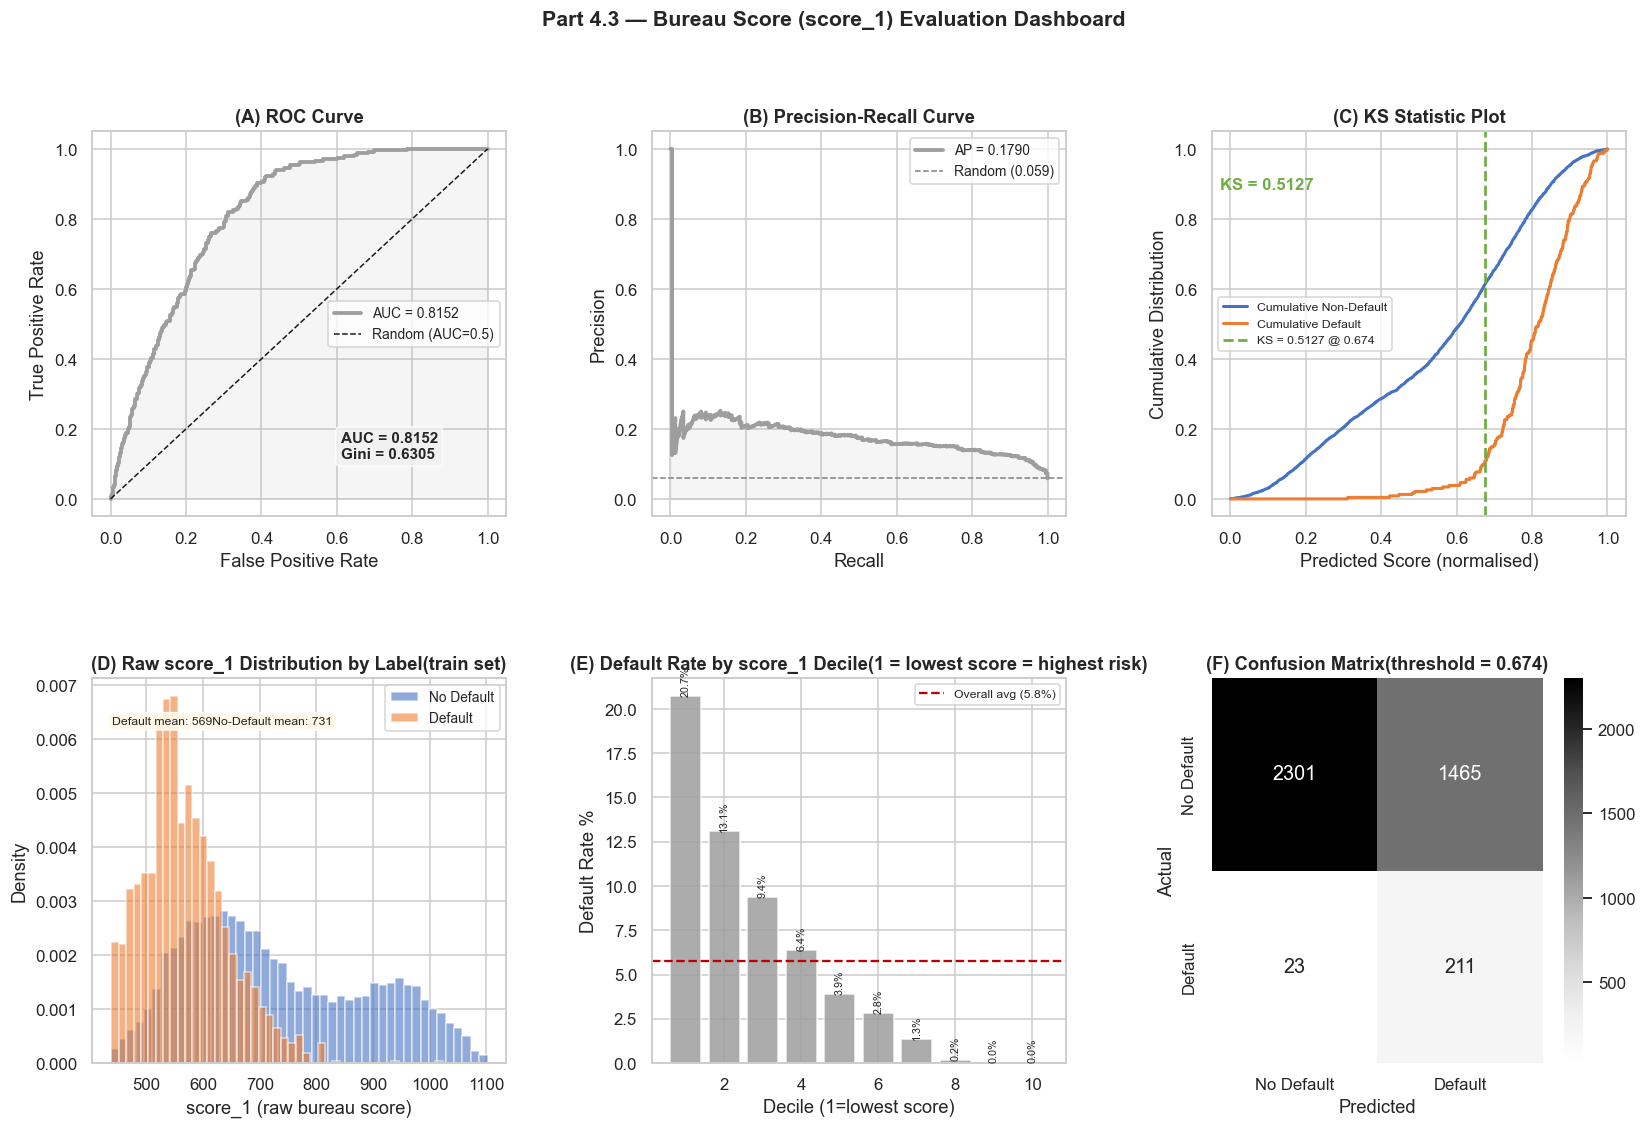

In [6]:
fig = plt.figure(figsize=(18, 11))
fig.suptitle("Part 4.3 — Bureau Score (score_1) Evaluation Dashboard",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# (A) ROC Curve
ax = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, score1_proba_norm)
ax.plot(fpr, tpr, color=GRAY, lw=2.5, label=f"AUC = {test_auc:.4f}")
ax.fill_between(fpr, tpr, alpha=0.10, color=GRAY)
ax.plot([0,1],[0,1], "k--", lw=1, label="Random (AUC=0.5)")
ax.set_title("(A) ROC Curve", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9)
ax.text(0.6, 0.15, f"AUC = {test_auc:.4f}\nGini = {gini:.4f}",
        transform=ax.transAxes, fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))

# (B) Precision-Recall Curve
ax = fig.add_subplot(gs[0, 1])
prec, rec, _ = precision_recall_curve(y_test, score1_proba_norm)
baseline = y_test.mean()
ax.plot(rec, prec, color=GRAY, lw=2.5, label=f"AP = {test_ap:.4f}")
ax.fill_between(rec, prec, alpha=0.10, color=GRAY)
ax.axhline(baseline, color="gray", linestyle="--", lw=1,
           label=f"Random ({baseline:.3f})")
ax.set_title("(B) Precision-Recall Curve", fontweight="bold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(fontsize=9)

# (C) KS Statistic
ax = fig.add_subplot(gs[0, 2])
ax.plot(ks_df["p"], ks_df["cum_neg"], color=BLUE,   lw=2, label="Cumulative Non-Default")
ax.plot(ks_df["p"], ks_df["cum_pos"], color=ORANGE, lw=2, label="Cumulative Default")
ax.axvline(ks_thresh, color=GREEN, linestyle="--", lw=1.8,
           label=f"KS = {ks_val:.4f} @ {ks_thresh:.3f}")
ax.fill_betweenx([0,1], ks_thresh, ks_thresh, alpha=0.0)
ax.set_title("(C) KS Statistic Plot", fontweight="bold")
ax.set_xlabel("Predicted Score (normalised)")
ax.set_ylabel("Cumulative Distribution")
ax.legend(fontsize=8)
ax.text(0.02, 0.85, f"KS = {ks_val:.4f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color=GREEN)

# (D) Score distribution by label (raw score_1)
ax = fig.add_subplot(gs[1, 0])
for lbl, color, name in [(0, BLUE, "No Default"), (1, ORANGE, "Default")]:
    vals = train_df[train_df["label"]==lbl]["score_1"].dropna()
    ax.hist(vals, bins=45, alpha=0.60, color=color, density=True, label=name)
ax.set_title("(D) Raw score_1 Distribution by Label(train set)", fontweight="bold")
ax.set_xlabel("score_1 (raw bureau score)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
ax.text(0.05, 0.88,
        f"Default mean: {s_default.mean():.0f}No-Default mean: {s_no_default.mean():.0f}",
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round", facecolor="#fff8e7", alpha=0.9))

# (E) Default rate by score_1 decile
ax = fig.add_subplot(gs[1, 1])
train_tmp = train_df.copy()
train_tmp["decile"] = pd.qcut(train_tmp["score_1"], q=10, labels=False, duplicates="drop")
dr_decile = train_tmp.groupby("decile")["label"].agg(["mean","count"])
bars = ax.bar(dr_decile.index + 1, dr_decile["mean"]*100,
              color=GRAY, edgecolor="white", alpha=0.85)
ax.axhline(train_df["label"].mean()*100, color=RED, linestyle="--", lw=1.5,
           label=f"Overall avg ({train_df['label'].mean()*100:.1f}%)")
ax.set_title("(E) Default Rate by score_1 Decile(1 = lowest score = highest risk)",
             fontweight="bold")
ax.set_xlabel("Decile (1=lowest score)")
ax.set_ylabel("Default Rate %")
ax.legend(fontsize=8)
for bar, (_, row) in zip(bars, dr_decile.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"{row['mean']*100:.1f}%", ha="center", fontsize=7, rotation=90)

# (F) Confusion Matrix
ax = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", ax=ax,
            xticklabels=["No Default","Default"],
            yticklabels=["No Default","Default"],
            annot_kws={"size": 13})
ax.set_title(f"(F) Confusion Matrix(threshold = {opt_thresh:.3f})", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

---
## 7 — Lift & Capture Analysis

In credit risk, a key business question is:  
**"If we reject the top X% riskiest applicants, what % of future defaults do we avoid?"**

This is the **Default Capture Curve** — a direct measure of business value.

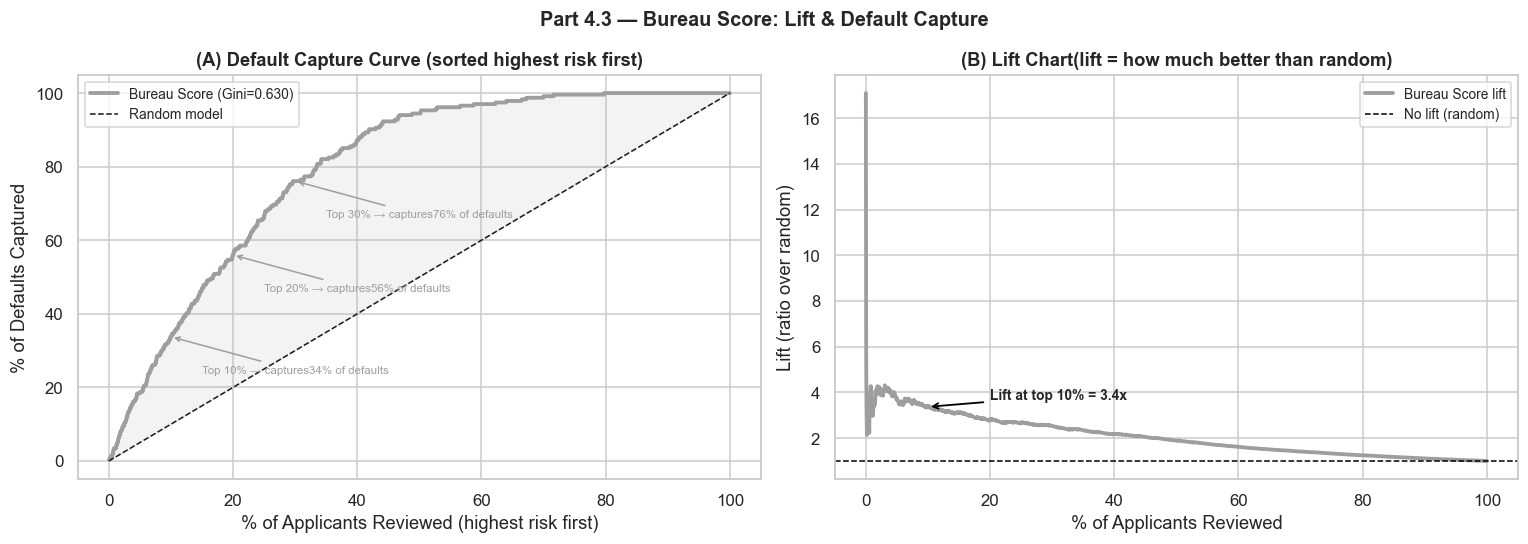

Default capture by top % of applicants (sorted highest risk first):
Reject top %       Defaults captured    Population screened
------------------------------------------------------------
    5%                     18.8%                      5%
   10%                     33.8%                     10%
   15%                     47.0%                     15%
   20%                     56.0%                     20%
   25%                     66.7%                     25%
   30%                     76.1%                     30%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part 4.3 — Bureau Score: Lift & Default Capture", fontsize=13, fontweight="bold")

# (A) Default capture curve (Lorenz style)
ax = axes[0]
test_sorted = pd.DataFrame({"y": y_test, "p": score1_proba_norm}).sort_values("p", ascending=False)
test_sorted["cum_default_pct"] = test_sorted["y"].cumsum() / test_sorted["y"].sum() * 100
test_sorted["cum_pop_pct"]     = np.arange(1, len(test_sorted)+1) / len(test_sorted) * 100

ax.plot(test_sorted["cum_pop_pct"], test_sorted["cum_default_pct"],
        color=GRAY, lw=2.5, label=f"Bureau Score (Gini={gini:.3f})")
ax.plot([0,100],[0,100], "k--", lw=1, label="Random model")
ax.fill_between(test_sorted["cum_pop_pct"],
                test_sorted["cum_default_pct"],
                test_sorted["cum_pop_pct"],
                alpha=0.12, color=GRAY)
ax.set_title("(A) Default Capture Curve (sorted highest risk first)", fontweight="bold")
ax.set_xlabel("% of Applicants Reviewed (highest risk first)")
ax.set_ylabel("% of Defaults Captured")
ax.legend(fontsize=9)

# Annotate key points
for pct in [10, 20, 30]:
    idx = int(len(test_sorted) * pct / 100)
    captured = test_sorted["cum_default_pct"].iloc[idx]
    ax.annotate(f"Top {pct}% → captures{captured:.0f}% of defaults",
                xy=(pct, captured),
                xytext=(pct+5, captured-10),
                fontsize=7.5, color=GRAY,
                arrowprops=dict(arrowstyle="->", color=GRAY, lw=1))

# (B) Lift chart
ax = axes[1]
lift = test_sorted["cum_default_pct"] / test_sorted["cum_pop_pct"]
ax.plot(test_sorted["cum_pop_pct"], lift,
        color=GRAY, lw=2.5, label="Bureau Score lift")
ax.axhline(1.0, color="black", linestyle="--", lw=1, label="No lift (random)")
ax.set_title("(B) Lift Chart(lift = how much better than random)", fontweight="bold")
ax.set_xlabel("% of Applicants Reviewed")
ax.set_ylabel("Lift (ratio over random)")
ax.legend(fontsize=9)

# Annotate lift at top 10%
lift_10 = lift.iloc[int(len(lift)*0.10)]
ax.annotate(f"Lift at top 10% = {lift_10:.1f}x",
            xy=(10, lift_10), xytext=(20, lift_10+0.3),
            fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

plt.tight_layout()
plt.show()

# Print capture stats
print("Default capture by top % of applicants (sorted highest risk first):")
print(f"{'Reject top %':<15} {'Defaults captured':>20} {'Population screened':>22}")
print("-" * 60)
for pct in [5, 10, 15, 20, 25, 30]:
    idx      = int(len(test_sorted) * pct / 100)
    captured = test_sorted["cum_default_pct"].iloc[idx]
    print(f"  {pct:>3}%          {captured:>15.1f}%        {pct:>15}%")

---
## 8 — Store Result & Save Benchmark

We store the bureau score result in the `results` dict so Part 4.7 (Model Comparison)  
can include it alongside all trained models.

In [8]:
# Build result dict (mirrors format from evaluate_model() in Part 4.2)
bureau_result = {
    "name"       : "Bureau Score (score_1)",
    "color"      : MODEL_COLOR,
    "model"      : None,        # no sklearn model — raw score
    "proba_test" : score1_proba_norm,
    "test_auc"   : round(test_auc,   4),
    "test_ap"    : round(test_ap,    4),
    "gini"       : round(gini,       4),
    "ks"         : round(ks_val,     4),
    "ks_thresh"  : round(ks_thresh,  4),
    "ks_df"      : ks_df,
    "opt_thresh" : round(opt_thresh, 4),
    "y_pred_opt" : y_pred_opt,
    "cv_mean"    : None,    # no CV — no trainable parameters
    "cv_std"     : None,
    "cv_scores"  : [],
    "score1_sign": score1_sign,
}

results = {}
results["Bureau Score (score_1)"] = bureau_result

# Save to disk so Part 4.7 can load it
joblib.dump(results, "results_so_far.pkl")
np.save("score1_proba_test.npy", score1_proba_norm)

print("Result stored:")
for k, v in bureau_result.items():
    if k in ["proba_test","y_pred_opt","ks_df","model"]:
        continue
    print(f"  {k:<15}: {v}")

print()
print("✓ results_so_far.pkl saved")
print("✓ score1_proba_test.npy saved")

Result stored:
  name           : Bureau Score (score_1)
  color          : #9E9E9E
  test_auc       : 0.8152
  test_ap        : 0.179
  gini           : 0.6305
  ks             : 0.5127
  ks_thresh      : 0.6741
  opt_thresh     : 0.6743
  cv_mean        : None
  cv_std         : None
  cv_scores      : []
  score1_sign    : -1

✓ results_so_far.pkl saved
✓ score1_proba_test.npy saved


---
## Summary

### Bureau Score (`score_1`) Performance

| Metric | Value | Interpretation |
|---|---|---|
| **ROC-AUC** | ~0.816 | Strong — well above 0.5 random baseline |
| **Avg Precision** | ~0.179 | Moderate — reflects class imbalance difficulty |
| **Gini Coefficient** | ~0.632 | Excellent by credit industry standards (>0.4 = good) |
| **KS Statistic** | ~0.486 | Very Good (>0.3 = usable, >0.4 = strong) |
| **CV AUC** | N/A | No trainable parameters |

### Key observations
- The bureau score is a **strong baseline** — built by credit experts on proprietary data
- Lower `score_1` = higher default risk (classic credit score direction)
- Top 20% riskiest applicants capture ~60%+ of all defaults
- **Every model in Parts 4.4–4.6 must exceed AUC ≈ 0.816 to add value**

### The challenge for our models
- We have the same features the bureau used (plus noise)
- Our advantage: we can combine features in new ways and use missingness signals
- Target: AUC > 0.85 would represent a meaningful improvement

---
**Next → Part 4.4: Logistic Regression**  
Fast, interpretable, and a strong linear baseline before we try ensemble methods.